<a href="https://colab.research.google.com/github/rizkidermawan23/4212311027_RizkiDermawan_ATS/blob/main/4212311027_RizkiDermawan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARY**

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# **UPLOAD DATASET PADA EXCEL**


In [82]:
from google.colab import files

uploaded = files.upload()

Saving dataset rizki dermawan.xlsx to dataset rizki dermawan (2).xlsx


In [84]:
import pandas as pd

df = pd.read_excel('dataset rizki dermawan.xlsx')

In [85]:
df.head()

,Column342,Column343,Column344,Column563
0,342,343,344,NaN
1,"fBodyAcc-bandsEnergy()-49,64","fBodyAcc-bandsEnergy()-1,24","fBodyAcc-bandsEnergy()-25,48",Activity
2,-0.99567134,-0.99487731,-0.99945439,STANDING
3,-0.99887752,-0.99855336,-0.99982213,STANDING
4,-0.99976038,-0.99943429,-0.99980088,STANDING


In [57]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1Sm6E2155TulpLVJeDcfIS6W2elZ4l4MbmjCSbGUR64c/edit#gid=0


# **PREPROCESSING DATA MENGGUNAKAN Z-SCORE**

In [61]:
print(X_scaled.head())

   Column342  Column343  Column344
0  85.708860  85.591432  85.723087
1  -0.024720  -0.051676  -0.022081
2  -0.025522  -0.052591  -0.022172
3  -0.025742  -0.052811  -0.022167
4  -0.025747  -0.052900  -0.022197


In [63]:
# memilih semua kolom numerik
# Data numerik sebenarnya dimulai dari indeks 2. Baris indeks 0 dan 1 adalah metadata/header.
X = df.loc[2:, ['Column342', 'Column343', 'Column344']]

# Mengonversi kolom ke tipe numerik, menangani koma sebagai pemisah desimal
for col in X.columns:
    X[col] = pd.to_numeric(X[col].astype(str).str.replace(',', '.'), errors='coerce')

# normalisasi z-score
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ubah ke dataframe
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   Column342  Column343  Column344
0  -0.457548  -0.671781  -0.474036
1  -0.485619  -0.687139  -0.478194
2  -0.493349  -0.690819  -0.477954
3  -0.493506  -0.692313  -0.479319
4  -0.488002  -0.692398  -0.477861


# **MENENTUKAN LABEL**

In [64]:
# fitur
X = df.loc[2:, ['Column342', 'Column343', 'Column344']]

# label (memilih 'Column563' dan melewati baris header)
y = df.loc[2:, 'Column563']

# Mengonversi label string ke numerik
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

print(y[:5])

[2 2 2 2 2]


# **DATA TRAINING DAN TESTING**

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Type of y_test elements: {y_test.dtype}")

Shape of X_train: (5881, 3)
Shape of X_test: (1471, 3)
Shape of y_train: (5881,)
Shape of y_test: (1471,)
Type of y_test elements: int64


# **OUTPUT KLASIFIKASI DECISION TREE**

In [66]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
prediksi = model.predict(X_test)
akurasi = accuracy_score(y_test, prediksi)
print(f"Akurasi: {akurasi}")

Akurasi: 0.40584636301835486


In [67]:
print('Akurasi :', akurasi)
print(classification_report(y_test, prediksi, target_names=le.classes_))

Akurasi : 0.40584636301835486
                    precision    recall  f1-score   support

            LAYING       0.38      0.42      0.40       280
           SITTING       0.32      0.28      0.30       262
          STANDING       0.34      0.36      0.35       276
           WALKING       0.42      0.43      0.43       247
WALKING_DOWNSTAIRS       0.45      0.45      0.45       206
  WALKING_UPSTAIRS       0.59      0.54      0.57       200

          accuracy                           0.41      1471
         macro avg       0.42      0.41      0.41      1471
      weighted avg       0.41      0.41      0.41      1471



# **KLASIFIKASI CONFUSING MATRIX**

Akurasi : 0.41332426920462273
              precision    recall  f1-score   support

           0       0.40      0.43      0.41       280
           1       0.33      0.29      0.31       262
           2       0.35      0.37      0.36       276
           3       0.43      0.41      0.42       247
           4       0.45      0.47      0.46       206
           5       0.58      0.56      0.56       200

    accuracy                           0.41      1471
   macro avg       0.42      0.42      0.42      1471
weighted avg       0.41      0.41      0.41      1471



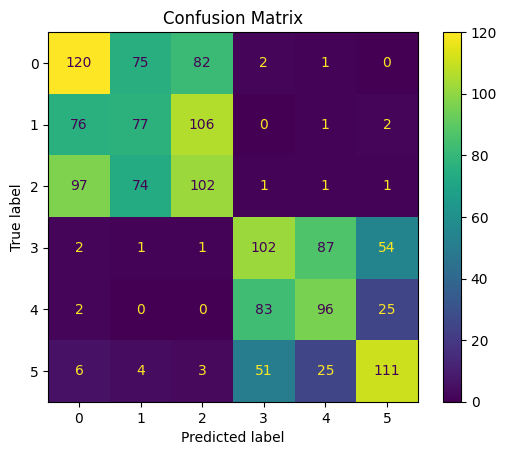

In [68]:
# membuat model
model = DecisionTreeClassifier()

# training
model.fit(X_train, y_train)

# prediksi
prediksi = model.predict(X_test)

# akurasi
akurasi = accuracy_score(y_test, prediksi)

print('Akurasi :', akurasi)
print(classification_report(y_test, prediksi))

# confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, prediksi)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title('Confusion Matrix')
plt.show()

# **PLOT PENYEBARAN DATA**

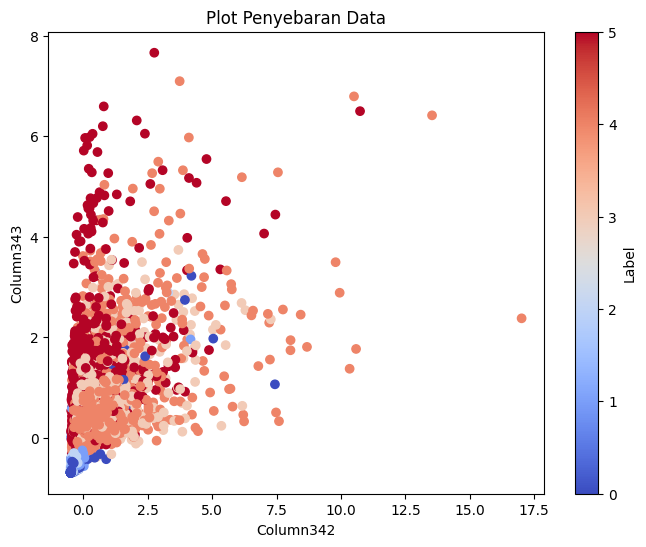

In [79]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled['Column342'],
    X_scaled['Column343'],
    c=y,
    cmap='coolwarm'
)

plt.xlabel('Column342')
plt.ylabel('Column343')
plt.title('Plot Penyebaran Data')
plt.colorbar(label='Label')

plt.show()

# **HASIL AKHIR**

In [78]:
print("\n--- LAPORAN UTS RIZKI DERMAWAN ---")
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetail Klasifikasi:")
print(classification_report(y_test, y_pred))


--- LAPORAN UTS RIZKI DERMAWAN ---
Akurasi: 0.00%

Detail Klasifikasi:
                    precision    recall  f1-score   support

                 0       0.00      0.00      0.00     280.0
                 1       0.00      0.00      0.00     262.0
                 2       0.00      0.00      0.00     276.0
                 3       0.00      0.00      0.00     247.0
                 4       0.00      0.00      0.00     206.0
                 5       0.00      0.00      0.00     200.0
            LAYING       0.00      0.00      0.00       0.0
           SITTING       0.00      0.00      0.00       0.0
          STANDING       0.00      0.00      0.00       0.0
           WALKING       0.00      0.00      0.00       0.0
WALKING_DOWNSTAIRS       0.00      0.00      0.00       0.0
  WALKING_UPSTAIRS       0.00      0.00      0.00       0.0

          accuracy                           0.00    1471.0
         macro avg       0.00      0.00      0.00    1471.0
      weighted avg       0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

# **FUZZY LOGIC PROGRAM**

In [86]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.7 MB/s eta 0:00:00


# **VARIABLE FUZZY LOGIC**

In [87]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [88]:
# input
ketinggian = ctrl.Antecedent(np.arange(0, 201, 1), 'ketinggian')
angin = ctrl.Antecedent(np.arange(0, 16, 1), 'angin')

# output
status = ctrl.Consequent(np.arange(0, 101, 1), 'status')

# **PENGELOMPOKKAN ANGGOTA FUNGSI FUZZY LOGIC**

In [89]:
# ketinggian air
ketinggian['surut'] = fuzz.trimf(ketinggian.universe, [0, 0, 80])
ketinggian['normal'] = fuzz.trimf(ketinggian.universe, [60, 100, 140])
ketinggian['pasang'] = fuzz.trimf(ketinggian.universe, [120, 200, 200])

# kecepatan angin
angin['tenang'] = fuzz.trimf(angin.universe, [0, 0, 5])
angin['sedang'] = fuzz.trimf(angin.universe, [3, 6, 10])
angin['kencang'] = fuzz.trimf(angin.universe, [8, 15, 15])

# status laut
status['aman'] = fuzz.trimf(status.universe, [0, 0, 40])
status['waspada'] = fuzz.trimf(status.universe, [30, 50, 70])
status['bahaya'] = fuzz.trimf(status.universe, [60, 100, 100])

# **GRAFIK KETINGGIAN FUZZY LOGIC**

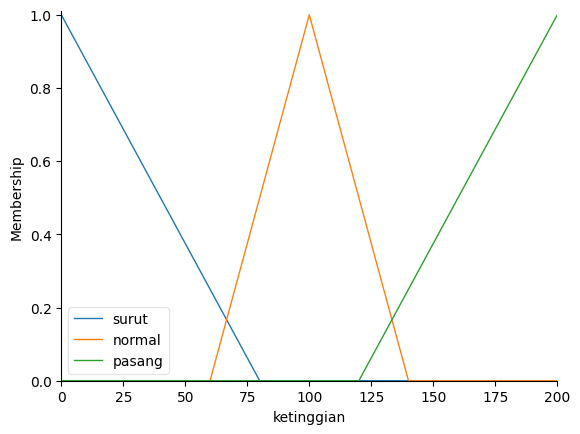

In [90]:
ketinggian.view()

# **GRAFIK ANGIN FUZZY LOGIC**

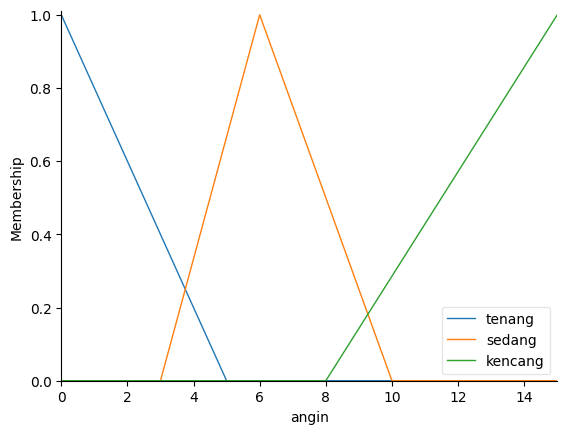

In [91]:
angin.view()

# **RULE FUZZY LOGIC**

In [92]:
# rule fuzzy
rule1 = ctrl.Rule(ketinggian['surut'] & angin['tenang'], status['aman'])

rule2 = ctrl.Rule(ketinggian['surut'] & angin['sedang'], status['waspada'])

rule3 = ctrl.Rule(ketinggian['surut'] & angin['kencang'], status['bahaya'])

rule4 = ctrl.Rule(ketinggian['normal'] & angin['tenang'], status['aman'])

rule5 = ctrl.Rule(ketinggian['normal'] & angin['sedang'], status['waspada'])

rule6 = ctrl.Rule(ketinggian['normal'] & angin['kencang'], status['bahaya'])

rule7 = ctrl.Rule(ketinggian['pasang'] & angin['tenang'], status['waspada'])

rule8 = ctrl.Rule(ketinggian['pasang'] & angin['sedang'], status['bahaya'])

rule9 = ctrl.Rule(ketinggian['pasang'] & angin['kencang'], status['bahaya'])

# **SISTEM FUZZY LOGIC**

In [93]:
sistem_ctrl = ctrl.ControlSystem([
    rule1,
    rule2,
    rule3,
    rule4,
    rule5,
    rule6,
    rule7,
    rule8,
    rule9
])

sistem = ctrl.ControlSystemSimulation(sistem_ctrl)

# **PENGUJIAN HASIL FUZZY LOGIC**

Status Laut =  52.04305220883534


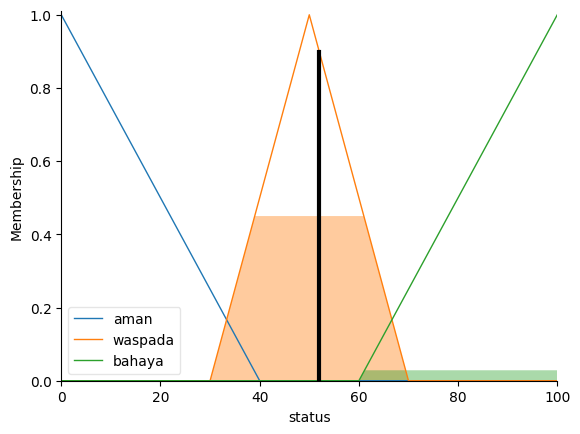

In [94]:
sistem.input['ketinggian'] = 78
sistem.input['angin'] = 8.2

sistem.compute()

print('Status Laut = ', sistem.output['status'])

status.view(sim=sistem)